In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sb
import os
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(
    dbname = "hh_central_asia",
    user = "postgres",
    password = os.getenv("DB_PASSWORD"),
    host = "localhost"
)

df = pd.read_sql(
    """
    SELECT 
        v.id,
        v.name,
        v.area_name,
        v.salary_from,
        v.salary_to,
        v.salary_currency,
        v.experience,
        v.employment,
        v.schedule,
        v.published_at,
        v.source_keyword,
        e.name as employer_name
    FROM vacancies v
    LEFT JOIN employers e ON v.employer_id = e.id
""", conn)

print(df.shape)
df.head()

(1309, 12)


/tmp/ipykernel_9686/3999533659.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,id,name,area_name,salary_from,salary_to,salary_currency,experience,employment,schedule,published_at,source_keyword,employer_name
0,133852207,AI Engineer,Ташкент,NaN,NaN,NaN,От 1 года до 3 лет,None,None,2026-06-04 10:50:18,AI engineer,«MY FREIGHTER» LLC
1,132913113,AI Engineer,Алматы,NaN,NaN,NaN,От 3 до 6 лет,None,None,2026-06-04 10:22:16,AI engineer,2ГИС-Справочник Двух Столиц
2,132791141,AI Solutions Engineer,Ташкент,NaN,NaN,NaN,От 1 года до 3 лет,None,None,2026-06-04 13:26:58,AI engineer,Itransition
3,133213438,"Backend Developer (Go/Python, AI Products)",Алматы,NaN,NaN,NaN,От 3 до 6 лет,None,None,2026-06-05 08:08:38,AI engineer,Choco (ТОО Chocofamily)
4,133859307,ML Engineer,Ташкент,NaN,NaN,NaN,От 1 года до 3 лет,None,None,2026-06-04 12:30:09,AI engineer,«MY FREIGHTER» LLC


In [2]:
# Убираем дубликаты
df = df.drop_duplicates(subset="id")
print("После дедупликации:", df.shape)

После дедупликации: (1309, 12)


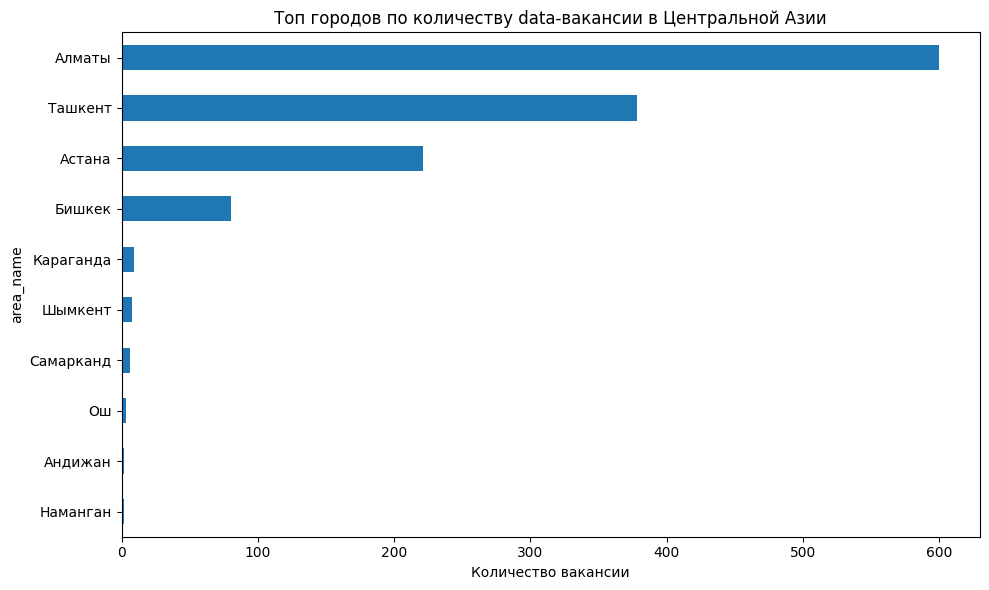

In [3]:
city_counts = df['area_name'].value_counts().head(15)

plt.figure(figsize=(10, 6))
city_counts.plot(kind="barh")
plt.title("Топ городов по количеству data-вакансии в Центральной Азии")
plt.xlabel('Количество вакансии')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/home/janibekabdurakhimov/Projects/hh_central_asia/reports/cities.png', dpi=150)
plt.show()


In [4]:
print("Вакансий с зарплатой:", df['salary_from'].notna().sum())
print("Вакансий без зарплатой:", df['salary_from'].isna().sum())
print()
print('Валюты:')
print(df['salary_currency'].value_counts())
print()
print('Опыт:')
print(df['experience'].value_counts())

Вакансий с зарплатой: 307
Вакансий без зарплатой: 1002

Валюты:
salary_currency
KZT    205
UZS     61
USD     39
KGS     26
RUR      4
EUR      2
Name: count, dtype: int64

Опыт:
experience
От 3 до 6 лет         614
От 1 года до 3 лет    510
Более 6 лет           134
Нет опыта              51
Name: count, dtype: int64


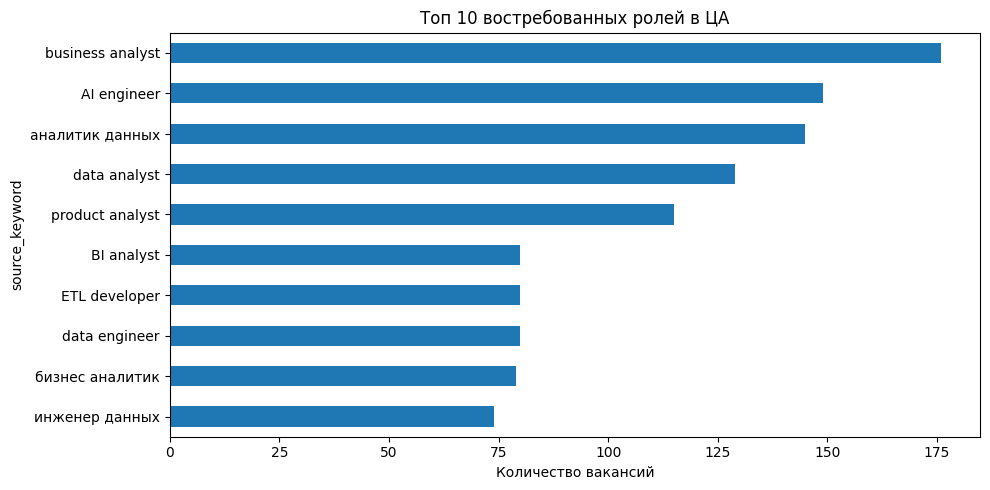

In [7]:
plt.figure(figsize=(10, 5))
df['source_keyword'].value_counts().head(10).plot(kind='barh')
plt.title('Топ 10 востребованных ролей в ЦА')
plt.xlabel('Количество вакансий')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/home/janibekabdurakhimov/Projects/hh_central_asia/reports/roles.png', dpi=150)
plt.show()